In [1]:
import numpy as np
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
from DESolver import DESolver
from problems_ODEs import ProblemsODE
from problems_PDEs import ProblemsPDE

import seaborn as sns
sns.set_context("talk", font_scale=1.) # "talk"

Solving Lorenz by using RK4


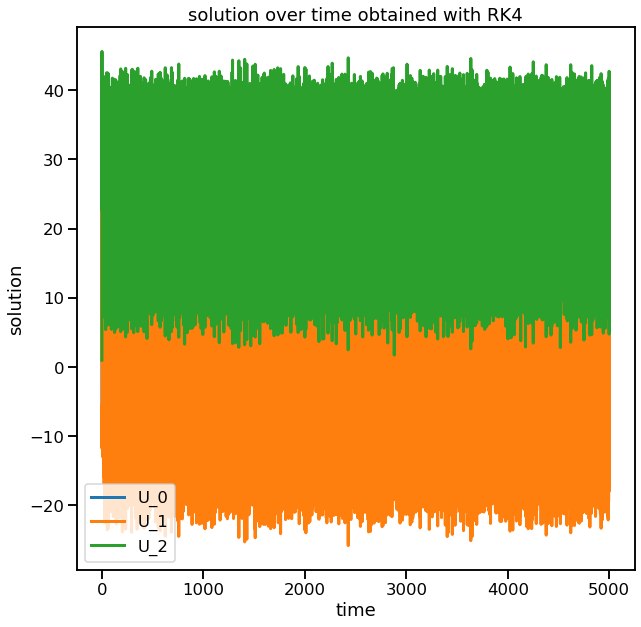

In [2]:
solver=DESolver()
solver.set_info(0)
rhs_e, rhs_i, u_ini, problem_setup, problem = ProblemsODE('Lorenz')
solver.setup()
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)
#solver.set_method('GLEE-A9')
solver.set_method('RK4')

if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)

problem_setup['DT']=0.1    
problem_setup['T_DURATION']['end']=5000.
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u,glee,_,_=solver.get_trajectory_GLEE()


fig = plt.figure(figsize=(10, 10))
for i in range(u.shape[0]):
    plt.plot(t,u[i,:],'-', lw=3, label = 'U_{:}'.format(i))
plt.ylabel('solution')
plt.xlabel('time')
plt.legend()
plt.title('solution over time obtained with {:}'.format(solver.get_method_name()))
plt.show()

No handles with labels found to put in legend.


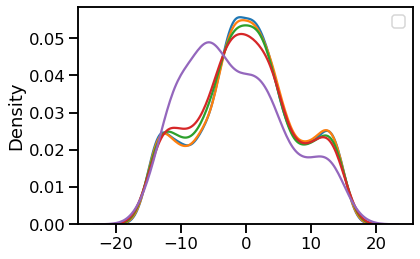

In [16]:
#sns.displot(data=penguins, x="flipper_length_mm", hue="species", col="sex", kind="kde")
idx=0
sns.kdeplot(np.transpose(u[idx,:]))
sns.kdeplot(np.transpose(u[idx,0:25000]))
sns.kdeplot(np.transpose(u[idx,0:10000]))
sns.kdeplot(np.transpose(u[idx,0:5000]))
sns.kdeplot(np.transpose(u[idx,0:1000]))
plt.legend()

In [4]:
u.shape

(3, 50001)

TypeError: The x variable is categorical, but one of ['numeric', 'datetime'] is required

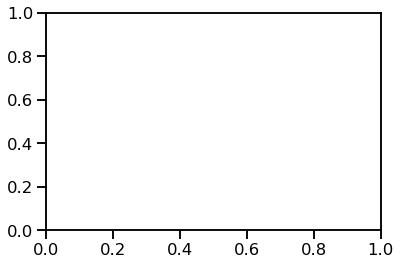

In [12]:
sns.kdeplot([np.transpose(u[idx,:]),np.transpose(u[idx,0:25000])])